In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory

In [2]:
base_path = "/kaggle/input/datasets/jehanbhathena/weather-dataset"

def find_data_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if dirnames and not filenames:
            sub_has_images = any(
                any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(os.path.join(dirpath, d)))
                for d in dirnames
            )
            if sub_has_images:
                return dirpath
    return root

data_dir = find_data_dir(base_path)
print("data_dir:", data_dir)
print("classes:", sorted(os.listdir(data_dir)))

data_dir: /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset
classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.


I0000 00:00:1786912748.936508      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786912748.939742      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 6862 files belonging to 11 classes.
Using 1372 files for validation.
['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [4]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train batches: 172
val batches: 22
test batches: 21


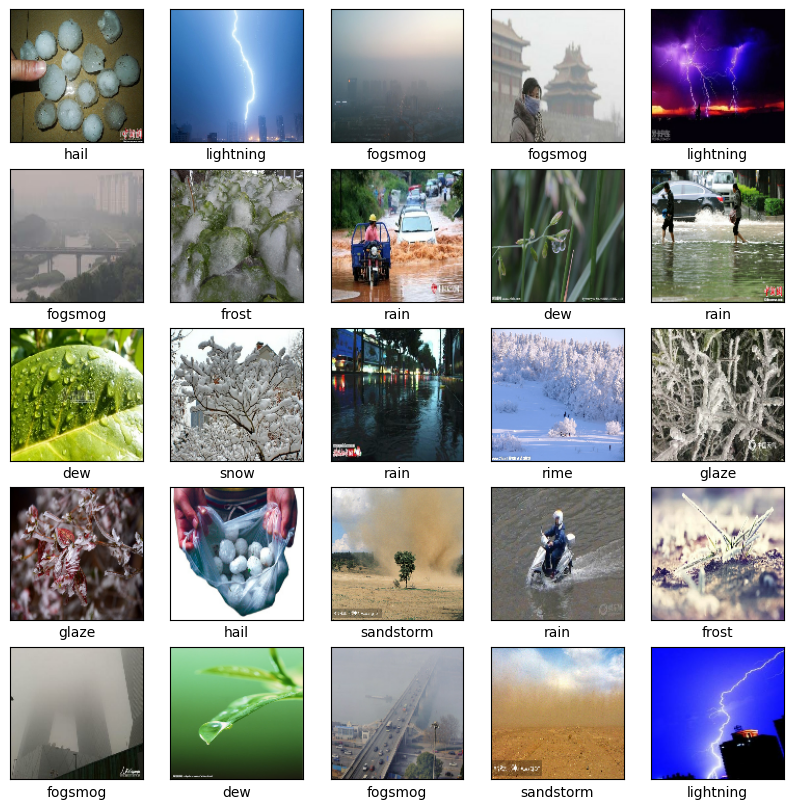

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(25, images.shape[0])):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.xlabel(class_names[labels[i]])
plt.show()

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

rescale = layers.Rescaling(1./255)

In [7]:
model = models.Sequential()
model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))
model.add(rescale)
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(num_classes))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,915 (3.28 MB)

 Trainable params: 859,915 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [12]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


2026-08-16 20:39:31.714666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 20:39:31.862569: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 13/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1549 - loss: 2.3696

I0000 00:00:1786912773.691667      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 33/172 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2130 - loss: 2.2454

2026-08-16 20:39:34.969468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-16 20:39:35.114648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


172/172 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.5071 - loss: 1.4535 - val_accuracy: 0.6257 - val_loss: 1.1478
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6548 - loss: 1.0345 - val_accuracy: 0.6857 - val_loss: 0.9928
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7075 - loss: 0.8748 - val_accuracy: 0.6514 - val_loss: 1.0278
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7441 - loss: 0.7637 - val_accuracy: 0.7171 - val_loss: 0.8973
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7856 - loss: 0.6463 - val_accuracy: 0.7171 - val_loss: 0.8929
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8284 - loss: 0.5107 - val_accuracy: 0.7200 - val_loss: 0.9589
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8650 - loss: 0.4056 - val_accuracy: 0.7429 - val_loss: 0.9543
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8969 - loss: 0.3136 - val_accuracy: 0.72

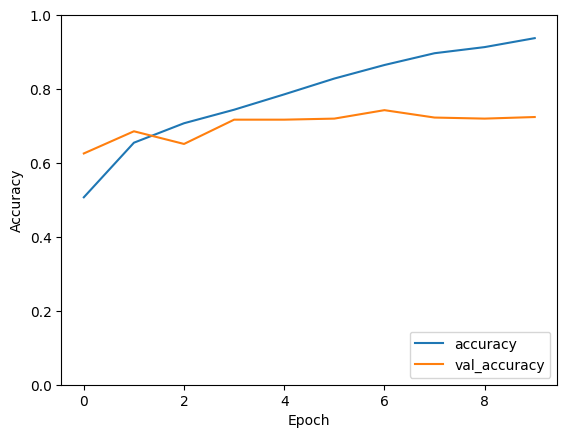

21/21 - 1s - 33ms/step - accuracy: 0.7217 - loss: 1.4297


In [13]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_ds, verbose=2)

In [14]:
print(test_acc)

0.7217261791229248


              precision    recall  f1-score   support

         dew       0.72      0.88      0.79        60
     fogsmog       0.66      0.88      0.76        76
       frost       0.83      0.58      0.68        50
       glaze       0.67      0.59      0.63        64
        hail       0.86      0.54      0.67        59
   lightning       0.94      0.92      0.93        53
        rain       0.55      0.73      0.63        45
     rainbow       0.67      0.61      0.64        23
        rime       0.68      0.81      0.74       118
   sandstorm       0.83      0.81      0.82        68
        snow       0.68      0.34      0.45        56

    accuracy                           0.72       672
   macro avg       0.74      0.70      0.70       672
weighted avg       0.73      0.72      0.71       672



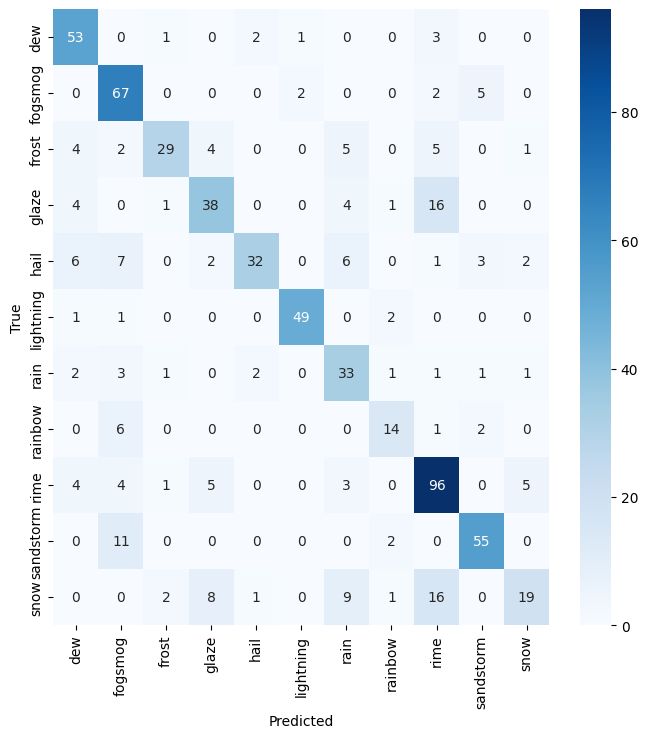

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()